In [1]:
import seaborn as sns
import pandas as pd
import tabula
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from scipy.stats import chisquare, monte_carlo_test
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display
from scipy.stats import chi2

def display_df(df):
    display(Markdown(df.to_markdown(index=False)))

# Exploring randomness in lottery drawings

Lottery drawings are designed to be random and impossible to predict. This notebook/project started out of mere curiosity about how trully random are lottery drawings in practice. To explore this question, I focus on Powerball, the largest and best-known lottery games in the United States, and examine how closely its observed number frequencies match the uniform distributions expected from a fair random process.

## Powerball format

Each Powerball drawing produces five distinct white-ball numbers selected without replacement from one pool and one red Powerball number selected from a separate pool. In the current format, the white-ball range is `1–69` and the red-ball range is `1–26`, but the range has varied historcally.

`Power Play` is a separately generated multiplier and does not affect which white or red numbers are selected. It is therefore excluded from the number-frequency analysis. `Double Play` uses the same white- and red-ball ranges but is a separate drawing, so its results are analyzed independently from the main Powerball results. Because the allowable number ranges have changed historically, drawings from different game formats are also analyzed separately.

The historical drawing results used in this analysis are available from the [Florida Lottery Powerball history](https://files.floridalottery.com/exptkt/pb.pdf).

# Data cleaning and sanitation

In [2]:
# fetch the latest updated data
!curl https://files.floridalottery.com/exptkt/pb.pdf -o pb.pdf

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 731.1k 100 731.1k   0      0  1.17M      0                              0


In [3]:
# ignore first page ==> additional content creates a parsing problems
df_lst_raw = tabula.read_pdf("pb.pdf", pages="2-90")

Failed to import jpype dependencies. Fallback to subprocess.
No module named 'jpype'


In [4]:
l = len(df_lst_raw)
print(l)

178


Why are there 178 elements instad of just 89?

In [5]:
display_df(df_lst_raw[0].head())

| Draw Date   |   Winning Numbers |   Game |   Unnamed: 0 |   Unnamed: 1 |   Unnamed: 2 | Unnamed: 3   | Unnamed: 4   | Unnamed: 5   |
|:------------|------------------:|-------:|-------------:|-------------:|-------------:|:-------------|:-------------|:-------------|
| 7/29/26     |                30 |     36 |           40 |           42 |           57 | PB 2         | X2           | POWERBALL    |
| 7/29/26     |                24 |     37 |           40 |           51 |           55 | PB 5         | nan          | POWERBALL DP |
| 7/27/26     |                 6 |     26 |           46 |           58 |           65 | PB 25        | X2           | POWERBALL    |
| 7/27/26     |                17 |     25 |           59 |           61 |           69 | PB 14        | nan          | POWERBALL DP |
| 7/25/26     |                 3 |      4 |           24 |           36 |           47 | PB 17        | X4           | POWERBALL    |

In [6]:
display_df(df_lst_raw[1])

| Pages2/91   |
|-------------|

Thats it! `tabula` is reading the page numbers as separate table. Those can be easily excluded by filtering out using the column name

In [7]:
df = df_lst_raw[0]
for _df in  df_lst_raw[2:]:
    if not any("Pages" in c for c in _df.columns):
        df = pd.concat([df, _df], axis=0, ignore_index=True)

In [8]:
display_df(df.head())

| Draw Date   |   Winning Numbers |   Game |   Unnamed: 0 |   Unnamed: 1 |   Unnamed: 2 | Unnamed: 3   | Unnamed: 4   | Unnamed: 5   |
|:------------|------------------:|-------:|-------------:|-------------:|-------------:|:-------------|:-------------|:-------------|
| 7/29/26     |                30 |     36 |           40 |           42 |           57 | PB 2         | X2           | POWERBALL    |
| 7/29/26     |                24 |     37 |           40 |           51 |           55 | PB 5         | nan          | POWERBALL DP |
| 7/27/26     |                 6 |     26 |           46 |           58 |           65 | PB 25        | X2           | POWERBALL    |
| 7/27/26     |                17 |     25 |           59 |           61 |           69 | PB 14        | nan          | POWERBALL DP |
| 7/25/26     |                 3 |      4 |           24 |           36 |           47 | PB 17        | X4           | POWERBALL    |

The column names are all messed up, lets fix them.

In [9]:
df = df.rename(columns = {"Draw Date": "date",
                     "Winning Numbers": "white_ball_1",
                     "Game": "white_ball_2",
                     "Unnamed: 0": "white_ball_3",
                     "Unnamed: 1": "white_ball_4",
                     "Unnamed: 2": "white_ball_5",
                     "Unnamed: 3": "red_ball", # Power Ball number
                     "Unnamed: 4": "pp_mult",  # Power Play multiplier
                     "Unnamed: 5": "game"})

In [10]:
display_df(df.head())

| date    |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 | red_ball   | pp_mult   | game         |
|:--------|---------------:|---------------:|---------------:|---------------:|---------------:|:-----------|:----------|:-------------|
| 7/29/26 |             30 |             36 |             40 |             42 |             57 | PB 2       | X2        | POWERBALL    |
| 7/29/26 |             24 |             37 |             40 |             51 |             55 | PB 5       | nan       | POWERBALL DP |
| 7/27/26 |              6 |             26 |             46 |             58 |             65 | PB 25      | X2        | POWERBALL    |
| 7/27/26 |             17 |             25 |             59 |             61 |             69 | PB 14      | nan       | POWERBALL DP |
| 7/25/26 |              3 |              4 |             24 |             36 |             47 | PB 17      | X4        | POWERBALL    |

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          2848 non-null   str  
 1   white_ball_1  2848 non-null   int64
 2   white_ball_2  2848 non-null   int64
 3   white_ball_3  2848 non-null   int64
 4   white_ball_4  2848 non-null   int64
 5   white_ball_5  2848 non-null   int64
 6   red_ball      2848 non-null   str  
 7   pp_mult       2075 non-null   str  
 8   game          2848 non-null   str  
dtypes: int64(5), str(4)
memory usage: 200.4 KB


Much better, but there's still some problemns. The `pb` and `pp` columns are `str` type and need to be `int`. Before they can be casted, the additinal characters (PB, X) must be removed from each column. The date is also a `str`, so needs to be converted to a date type if date operation are needed.

In [12]:
df['red_ball'] = df['red_ball'].str.replace('PB ', '', regex=False)
df['pp_mult'] = df['pp_mult'].str.replace('X', '', regex=False)

In [13]:
df['red_ball'] = df['red_ball'].astype(int)
# the astype method cannot be used directly with the pp column since it contain NaN strings which cannot be
# casted to int directly. Instead we use the to_numeric method with the "coerce" option which forces the casting
# on the valid elements but asigns NaN to the unvalid ones.
df['pp_mult'] = pd.to_numeric(df['pp_mult'], errors="coerce").astype("Int64")
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_1389763/528970629.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [14]:
display_df(df.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball | pp_mult   | game         |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|:----------|:-------------|
| 2026-07-29 00:00:00 |             30 |             36 |             40 |             42 |             57 |          2 | 2         | POWERBALL    |
| 2026-07-29 00:00:00 |             24 |             37 |             40 |             51 |             55 |          5 | <NA>      | POWERBALL DP |
| 2026-07-27 00:00:00 |              6 |             26 |             46 |             58 |             65 |         25 | 2         | POWERBALL    |
| 2026-07-27 00:00:00 |             17 |             25 |             59 |             61 |             69 |         14 | <NA>      | POWERBALL DP |
| 2026-07-25 00:00:00 |              3 |              4 |             24 |             36 |             47 |         17 | 4         | POWERBALL    |

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2848 non-null   datetime64[us]
 1   white_ball_1  2848 non-null   int64         
 2   white_ball_2  2848 non-null   int64         
 3   white_ball_3  2848 non-null   int64         
 4   white_ball_4  2848 non-null   int64         
 5   white_ball_5  2848 non-null   int64         
 6   red_ball      2848 non-null   int64         
 7   pp_mult       2075 non-null   Int64         
 8   game          2848 non-null   str           
dtypes: Int64(1), datetime64[us](1), int64(6), str(1)
memory usage: 203.2 KB


Data looks good now, so we can go ahead and save the cleaned version to disk.

In [16]:
df.to_csv("powerball_numbers_cleaned.csv", index=False)

## Consistency Checks

In the powerball drawing, the number of the 5 white balls should be in the range `[1-69]`. The red ball (power ball) numbers should be in the range `[1-26]`

In [17]:
assert df[[f"white_ball_{x}" for x in range(1,6)]].min(axis=None) >= 1,  "White ball numbers out of range!"
assert df[[f"white_ball_{x}" for x in range(1,6)]].max(axis=None) <= 69, "White ball numbers out of range!"

In [18]:
assert df["red_ball"].min(axis=None) >= 1,  "Red (Power) ball numbers out of range!"
assert df["red_ball"].max(axis=None) <= 26, "Red (Power) ball numbers out of range!"

AssertionError: Red (Power) ball numbers out of range!

In [19]:
df["red_ball"].max(axis=None)

np.int64(39)

But why? Turns out there have been several versions of the powerball with different ball numbering ranges. [Seven](https://www.usamega.com/powerball/statistics) versions in total to be precise. The availbale data starts on January 7, 2009 and cover the last three versions: versions 5, 6 and 7 (the current version).
|version  |  start date  | end date   | white ball range  | red ball range |
|---------|------------- |------------|-------------------|-----------------
|5        | 2009-01-07   | 2012-01-14 |  1-59             | 1-39           |
|6        | 2012-01-18   | 2015-10-03 |  1-59             | 1-35           |
|7        | 2015-10-07   | present    |  1-69             | 1-26           |

The dataset must be split into these cases to avoid skewing the statistical results.

In [20]:
df_v5 = df[ (df["date"] >= "2009-01-07") & (df["date"] <= "2012-01-14")]
assert df_v5["red_ball"].max(axis=None) == 39, "Power ball numbers out of range!"
display_df(df_v5.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball |   pp_mult | game      |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|----------:|:----------|
| 2012-01-14 00:00:00 |             10 |             30 |             36 |             38 |             41 |          1 |         5 | POWERBALL |
| 2012-01-11 00:00:00 |              5 |             19 |             29 |             45 |             47 |         25 |         2 | POWERBALL |
| 2012-01-07 00:00:00 |              3 |             21 |             24 |             38 |             39 |         24 |         5 | POWERBALL |
| 2012-01-04 00:00:00 |             21 |             35 |             46 |             47 |             50 |          2 |         4 | POWERBALL |
| 2011-12-31 00:00:00 |              5 |             23 |             25 |             28 |             40 |         34 |         4 | POWERBALL |

In [21]:
df_v6 = df[ (df["date"] >= "2012-01-18") & (df["date"] <= "2015-10-03")]
assert df_v6["red_ball"].max(axis=None) == 35, "Power ball numbers out of range!"
display_df(df_v6.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball |   pp_mult | game      |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|----------:|:----------|
| 2015-10-03 00:00:00 |              6 |             26 |             33 |             44 |             46 |          4 |         2 | POWERBALL |
| 2015-09-30 00:00:00 |             21 |             39 |             40 |             55 |             59 |         17 |         3 | POWERBALL |
| 2015-09-26 00:00:00 |             23 |             31 |             42 |             50 |             57 |          5 |         3 | POWERBALL |
| 2015-09-23 00:00:00 |              8 |             29 |             41 |             51 |             58 |          5 |         2 | POWERBALL |
| 2015-09-19 00:00:00 |             12 |             17 |             26 |             43 |             48 |         24 |         2 | POWERBALL |

In [22]:
df_v7 = df[df["date"] >= "2015-10-07"]
assert df_v7["red_ball"].max(axis=None) == 26, "Power ball numbers out of range!"
display_df(df_v7.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball | pp_mult   | game         |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|:----------|:-------------|
| 2026-07-29 00:00:00 |             30 |             36 |             40 |             42 |             57 |          2 | 2         | POWERBALL    |
| 2026-07-29 00:00:00 |             24 |             37 |             40 |             51 |             55 |          5 | <NA>      | POWERBALL DP |
| 2026-07-27 00:00:00 |              6 |             26 |             46 |             58 |             65 |         25 | 2         | POWERBALL    |
| 2026-07-27 00:00:00 |             17 |             25 |             59 |             61 |             69 |         14 | <NA>      | POWERBALL DP |
| 2026-07-25 00:00:00 |              3 |              4 |             24 |             36 |             47 |         17 | 4         | POWERBALL    |

In [23]:
df_v7["game"].unique().tolist()

['POWERBALL', 'POWERBALL DP']

Note that `v7` has two different values in the `game` column: `POWERBALL` and `POWERBALL DP`. The former is the plain old powerball draw while the latter refers to the douple play (hence DP) draw. The double play draw was introduced in August 23, 2021. Note that this falls within version 7 so thats why `POWERBALL DP` is missing from the other dataframes. Lets confirm this to make sure we split the data correctly.

In [24]:
print("Unique games in v5:", df_v5["game"].unique().tolist())
print("Unique games in v6:",df_v6["game"].unique().tolist())
print("Earliest date of POWERBALL DP in v7:", df_v7[df_v7["game"] == "POWERBALL DP"]["date"].min())

Unique games in v5: ['POWERBALL']
Unique games in v6: ['POWERBALL']
Earliest date of POWERBALL DP in v7: 2021-08-23 00:00:00


The earliest occurence of a `POWERBALL DP` value in the `game` column of `v7` matches our expectation of August 23, 2021. To avoid mixing things up, lets further split the `v7` data based on the game column.

In [25]:
df_v7_pb = df_v7[ df_v7["game"] == "POWERBALL" ]
df_v7_dp = df_v7[ df_v7["game"] == "POWERBALL DP" ]

In [26]:
display_df(df_v7_pb.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball |   pp_mult | game      |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|----------:|:----------|
| 2026-07-29 00:00:00 |             30 |             36 |             40 |             42 |             57 |          2 |         2 | POWERBALL |
| 2026-07-27 00:00:00 |              6 |             26 |             46 |             58 |             65 |         25 |         2 | POWERBALL |
| 2026-07-25 00:00:00 |              3 |              4 |             24 |             36 |             47 |         17 |         4 | POWERBALL |
| 2026-07-22 00:00:00 |              4 |              5 |             22 |             50 |             58 |          1 |         3 | POWERBALL |
| 2026-07-20 00:00:00 |              2 |              9 |             44 |             53 |             59 |          8 |         2 | POWERBALL |

In [27]:
display_df(df_v7_dp.head())

| date                |   white_ball_1 |   white_ball_2 |   white_ball_3 |   white_ball_4 |   white_ball_5 |   red_ball | pp_mult   | game         |
|:--------------------|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|:----------|:-------------|
| 2026-07-29 00:00:00 |             24 |             37 |             40 |             51 |             55 |          5 | <NA>      | POWERBALL DP |
| 2026-07-27 00:00:00 |             17 |             25 |             59 |             61 |             69 |         14 | <NA>      | POWERBALL DP |
| 2026-07-25 00:00:00 |             20 |             21 |             26 |             28 |             32 |         10 | <NA>      | POWERBALL DP |
| 2026-07-22 00:00:00 |              9 |             51 |             54 |             60 |             61 |         15 | <NA>      | POWERBALL DP |
| 2026-07-20 00:00:00 |             15 |             21 |             39 |             54 |             67 |          7 | <NA>      | POWERBALL DP |

This concludes the data preparation step.

# Statistical Analysis

To begin, lets take a look at the frequency distribution of the white and red balls for each version of the drawing separately.


In [28]:
white_ball_cols = ["white_ball_1","white_ball_2", "white_ball_3", "white_ball_4", "white_ball_5"]

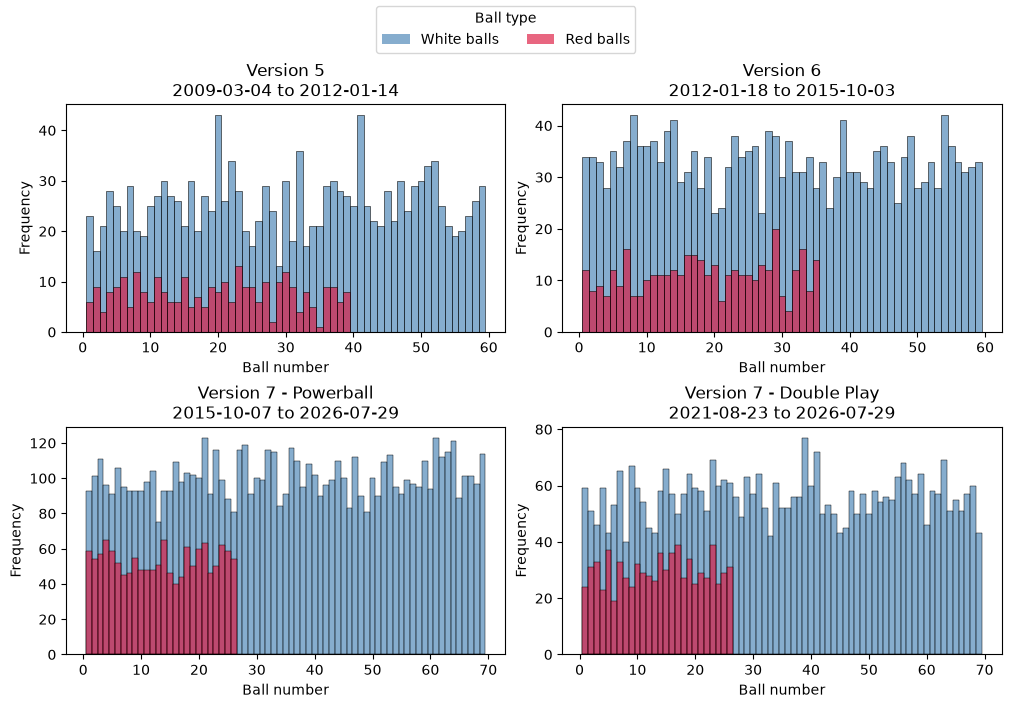

In [29]:
fig, axes = plt.subplots(2,2,figsize=(10, 7),layout="constrained")

white_color = "steelblue"
red_color = "crimson"

groups = [
            (axes[0, 0], df_v5,    "Version 5"),
            (axes[0, 1], df_v6,    "Version 6"),
            (axes[1, 0], df_v7_pb, "Version 7 - Powerball"),
            (axes[1, 1], df_v7_dp, "Version 7 - Double Play"),
]

for ax, data, name in groups:
    # White-ball frequency distribution
    sns.histplot(
                data[white_ball_cols].to_numpy().flatten(),
                stat="count",
                discrete=True,
                color=white_color,
                alpha=0.65,
                ax=ax
                )

    # Red-ball frequency distribution
    sns.histplot(
                data["red_ball"],
                stat="count",
                discrete=True,
                color=red_color,
                alpha=0.65,
                ax=ax
                )

    # Format the minimum and maximum dates for the subplot title.
    start_date = data["date"].min().strftime("%Y-%m-%d")
    end_date = data["date"].max().strftime("%Y-%m-%d")

    ax.set_title(f"{name}\n{start_date} to {end_date}")
    ax.set_xlabel("Ball number")
    ax.set_ylabel("Frequency")

# Proxy patches create one shared legend for the entire figure.
legend_handles = [ Patch(facecolor=white_color, alpha=0.65, label="White balls"),
                   Patch(facecolor=red_color, alpha=0.65, label="Red balls")
                 ]

fig.legend(
            handles=legend_handles,
            loc="outside upper center",
            ncols=2,
            title="Ball type"
            )

plt.show()

The Version 7 histograms appear reasonably uniform by visual inspection, whereas the Version 5 and Version 6 distributions show more noticeable variations. This apparent difference can likely be explained, at least in part, by sample size. Versions 5 and 6 contain considerably fewer drawings than Version 7, so their observed frequencies are expected to fluctuate more strongly.

In [30]:
print(f"Version 5 drawings: {len(df_v5)}")
print(f"Version 6 drawings: {len(df_v6)}")
print(f"Version 7 - Powerball drawings: {len(df_v7_pb)}")
print(f"Version 7 - Powerball drawings: {len(df_v7_dp)}")

Version 5 drawings: 300
Version 6 drawings: 388
Version 7 - Powerball drawings: 1387
Version 7 - Powerball drawings: 773


Visual inspection is a good starting point, but it alone cannot tell us whether the differences in the histograms represent real nonuniformity or ordinary random variation. This is especially important here because the categories contain different numbers of drawings. Categories with fewer drawings will naturally produce noisier-looking histograms.

A standard chi-square test works for the red ball because only one red ball is selected in each drawing. It is not directly applicable to the pooled white-ball counts because the five white balls in each drawing are selected without replacement. Once one white ball has been selected, it cannot be selected again in the same drawing, so the five selections are not independent.

A Monte Carlo goodness-of-fit test handles this by simulating the actual drawing process, including the correct number of drawings, number range, and without-replacement rule. The deviation from uniformity in the observed data is then compared with the deviations found in many simulated fair datasets. Because eight distributions are tested, the Holm correction is also applied to reduce the chance of treating an ordinary random fluctuation as statistically significant.

### Null hypothesis

For each drawing regime and ball type, the null hypothesis is that the balls are drawn fairly and uniformly.

For the red ball, this means that every number in the allowed range has the same probability of being selected. For the white balls, it means that every possible set of five unique numbers is equally likely. As a result, every individual white-ball number has the same probability of appearing in a drawing, even though the five selections within that drawing are not independent. The drawing results are also assumed to be independent from one drawing to the next.

The alternative hypothesis is that at least one ball number has a different probability of being selected than expected under this fair-drawing model.

### Monte Carlo goodness-of-fit procedure

Each drawing regime and ball type is analyzed separately. First, the observed results are converted into a frequency vector,

$$
\mathbf{O} = (O_1, O_2, \ldots, O_N),
$$

where $O_i$ is the number of times ball $i$ appeared and $N$ is the number of possible ball numbers.

For a dataset containing $D$ drawings, the expected count for each red-ball number under a uniform distribution is

$$
E_{\mathrm{red}} = \frac{D}{N}.
$$

Because each drawing contains five white balls, the expected count for each white-ball number is

$$
E_{\mathrm{white}} = \frac{5D}{N}.
$$

The difference between the observed and expected frequencies is summarized using the Pearson discrepancy statistic,

$$
\chi^2_{\mathrm{obs}}=
\sum_{i=1}^{N}
\frac{(O_i-E_i)^2}{E_i},
$$

where $E_i$ is the appropriate expected count for the ball type being analyzed. A larger value of $\chi^2_{\mathrm{obs}}$ means that the observed frequencies are farther from the frequencies expected under uniform drawing.

For each Monte Carlo resample, a complete fair dataset containing the same number of drawings as the observed dataset is generated. For the red ball, one number is selected uniformly from the allowed range in every drawing. For the white balls, five unique numbers are selected without replacement in every drawing. This preserves the dependence among the five white balls.

The simulated drawings are converted into frequency counts, and the same statistic is calculated. Repeating this process $B=10000$ times produces the simulated statistics

$$
\chi^2_1, \chi^2_2, \ldots, \chi^2_B.
$$

Let $b$ be the number of simulations for which

$$
\chi^2_j \geq \chi^2_{\mathrm{obs}}.
$$

The Monte Carlo p-value is then

$$
p_{\mathrm{MC}}=
\frac{b+1}{B+1}.
$$

The p-value tells us how often a fair simulated dataset produces a deviation at least as large as the one found in the observed data. A small p-value means that very few fair simulations were as uneven as the observed data, providing evidence against the null hypothesis. A large p-value means that the observed amount of unevenness is reasonably common under fair random drawing. It does not prove that the distribution is perfectly uniform.

Because every simulated dataset uses the same number of drawings and the same number range as its corresponding observed dataset, this procedure automatically accounts for the differences among drawing regimes. It is particularly useful for the white balls because it preserves the without-replacement rule that is missing from an ordinary Pearson chi-square test based on independent selections.

Eight separate distributions are analyzed, so eight p-values are produced. These p-values are adjusted using the Holm procedure. This correction controls the overall chance of making one or more false-positive conclusions across the eight tests. The Holm correction does not change the simulations or the individual test statistics; it only changes the threshold used to decide whether any of the eight results is statistically significant.

Fortunately, `scipy.stats` provides the `monte_carlo_test` function, which handles the resampling procedure, constructs the null distribution of the statistic, and calculates the Monte Carlo p-value. The observed frequency vector is supplied through the `data` argument, while custom functions specify how fair lottery datasets are generated and how the Pearson discrepancy statistic is calculated.


In [31]:
def compute_chisquare(observed_counts, axis=-1):
    """
    Wrapper function around SciPy's built-in chisquare

    Parameters
    ----------
    observed_counts:
        shape = (n_possible,) OR (batch_size, n_possible)
        
    axis:
        axis of the input along which to compute statistic
    """
    return chisquare(observed_counts, axis=axis).statistic


def make_fair_draws_generator( n_draws,
                                n_possible,
                                balls_per_draw,
                                rng):
    """
    Factory that creates a fair-count generator configured
    for one Powerball distribution.

    Parameters
    ----------
    n_draws:
        Number of drawings in each simulated dataset.

    n_possible:
        Number of possible ball numbers.

    balls_per_draw:
        Number of balls selected in each drawing:
            1 for red balls
            5 for white balls

    rng:
        NumPy random-number generator.

    Returns
    -------
    generate_fair_counts:
        Function with the rvs(size) interface required by
        scipy.stats.monte_carlo_test.
    """

    if n_draws <= 0:
        raise ValueError("n_draws must be positive.")

    if n_possible <= 0:
        raise ValueError("n_possible must be positive.")

    if not 1 <= balls_per_draw <= n_possible:
        raise ValueError("balls_per_draw must be between 1 and n_possible.")
    

    def generate_fair_counts(size):
        """
        Generate simulated count vectors.

        SciPy supplies size in the form:

            (number of simulations, number of categories)
        """

        n_simulations = size[0]

        if balls_per_draw == 1:
            # Generate aggregate counts from n_draws independent red-ball drawings.
            uniform_probabilities = np.full(n_possible, 1/n_possible)
            # Use multinomial because there are n_possible choices, and only 
            # one is selected each draw. An experiment or dataset consists of
            # n_draws and each of these experiments is repeated n_simulations times.
            simulated_counts = rng.multinomial(n=n_draws,
                                               pvals=uniform_probabilities,
                                               size=n_simulations)
        else:
            # Generate n_draws selections without replacement for every simulated dataset.
            simulated_draws = rng.multivariate_hypergeometric(colors = np.ones(n_possible, dtype=int),
                                                              nsample=balls_per_draw,
                                                              size=(n_simulations, n_draws))

            # Input shape:
            # (n_simulations, n_draws, n_possible)
            #
            # Output shape:
            # (n_simulations, n_possible)
            simulated_counts = simulated_draws.sum(axis=1)

        return simulated_counts

    return generate_fair_counts


def run_uniformity_test(data_frame,
                        ball_columns,
                        n_possible,
                        balls_per_draw,
                        rng,
                        n_samples = 10_000,
                        batch_size = 50):
    """
    Test whether one ball distribution is consistent with
    uniform random drawing.
    
    Parameters
    ----------
    data_frame:
        Pandas data frame containing draw data

    ball_columns:
        columns of the data frame containing winning numbers
            - white_ball_{1-5} for white balls draws
            - red_ball for red ball draws

    balls_per_draw:
        Number of balls selected in each drawing:
            - 1 for red balls
            - 5 for white balls
    rng:
        NumPy random-number generator.

    n_samples:
        Number of MC experiments to perform on each dataset

    batch_size:
        The number of Monte Carlo samples to process in each call.
    """
    
    n_draws = len(data_frame)
    
    if n_draws == 0:
        raise ValueError("Empty dataset")

    # raw values
    observed_values = data_frame[ball_columns].to_numpy(dtype=int).flatten()

    observed_counts = np.bincount(observed_values, minlength = n_possible +1)[1:] # exclude zero

    make_fair_draws = make_fair_draws_generator( n_draws,
                                                 n_possible,
                                                 balls_per_draw,
                                                 rng)

    result = monte_carlo_test( data=observed_counts,
                               rvs=make_fair_draws,
                               statistic=compute_chisquare,
                               vectorized=True,
                               n_resamples=n_samples,
                               batch=batch_size,
                               alternative="greater")
    return result

In [32]:
def plot_monte_carlo_distribution(result, title, ax=None):
    """
    Plot the Monte Carlo null distribution for one test.

    result:
        Object returned by scipy.stats.monte_carlo_test.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    simulated_chi_sq = np.asarray(result.null_distribution).flatten()
    observed_chi_sq = result.statistic
    pvalue = result.pvalue

    ax.hist(
        simulated_chi_sq,
        bins=40,
        color="steelblue",
        alpha=0.75,
        edgecolor="white"
    )

    ax.axvline(
        observed_chi_sq,
        color="darkred",
        linestyle="--",
        linewidth=2,
        label=fr"Observed $\chi^2={observed_chi_sq:.2f}$"
    )

    # add empty element so that p value appears in legend
    ax.plot(
        [],
        color="darkred",
        linestyle="",
        linewidth=0,
        label=fr"$p={pvalue:.3f}$"
    )

    ax.set_title(title)
    ax.set_xlabel(r"Simulated $\chi^2$")
    ax.set_ylabel("Number of simulations")
    ax.legend()

Now we compute the results for each fo the eight distributions and store them in a dataframe and plot the simulated distributions along with their respective $\chi$ and p values

In [33]:
rng = np.random.default_rng(seed = 10)

# Each tuple contains:
# name, dataframe, white-ball maximum, red-ball maximum
datasets = [("v5", df_v5, 59, 39),
            ("v6", df_v6, 59, 35),
            ("v7_pb", df_v7_pb, 69, 26),
            ("v7_dp", df_v7_dp, 69, 26)]

results_dict = { "draw_version":[],
                 "ball_color":[], 
                 "n_draws": [],
                 "chi_sq": [],
                 "p_value": [],}

# collect results from the monte_carlo_test function for plotting later
results_mc_test = []

# perform MC simulations for each dataset
for version, df, n_white, n_red in datasets:

    white_result = run_uniformity_test(df,
                                       white_ball_cols,
                                       n_white,
                                       balls_per_draw=5,
                                       rng=rng)
    results_dict["draw_version"].append(version)
    results_dict["n_draws"].append(len(df))
    results_dict["ball_color"].append("white")
    results_dict["p_value"].append(white_result.pvalue)
    results_dict["chi_sq"].append(white_result.statistic)

    red_result = run_uniformity_test(df,
                                     "red_ball",
                                      n_red,
                                      balls_per_draw=1,
                                      rng=rng)
    results_dict["draw_version"].append(version)
    results_dict["n_draws"].append(len(df))
    results_dict["ball_color"].append("red")
    results_dict["p_value"].append(red_result.pvalue)
    results_dict["chi_sq"].append(red_result.statistic)

    results_mc_test.append((version, "white balls", white_result))
    results_mc_test.append((version, "red balls", red_result))
                  
results_df = pd.DataFrame(results_dict)

In [34]:
display_df(results_df.head())

| draw_version   | ball_color   |   n_draws |   chi_sq |   p_value |
|:---------------|:-------------|----------:|---------:|----------:|
| v5             | white        |       300 |  78.7613 | 0.0131987 |
| v5             | red          |       300 |  36.7    | 0.531047  |
| v6             | white        |       388 |  37.1082 | 0.968903  |
| v6             | red          |       388 |  32.5412 | 0.537146  |
| v7_pb          | white        |      1387 |  80.3449 | 0.0756924 |

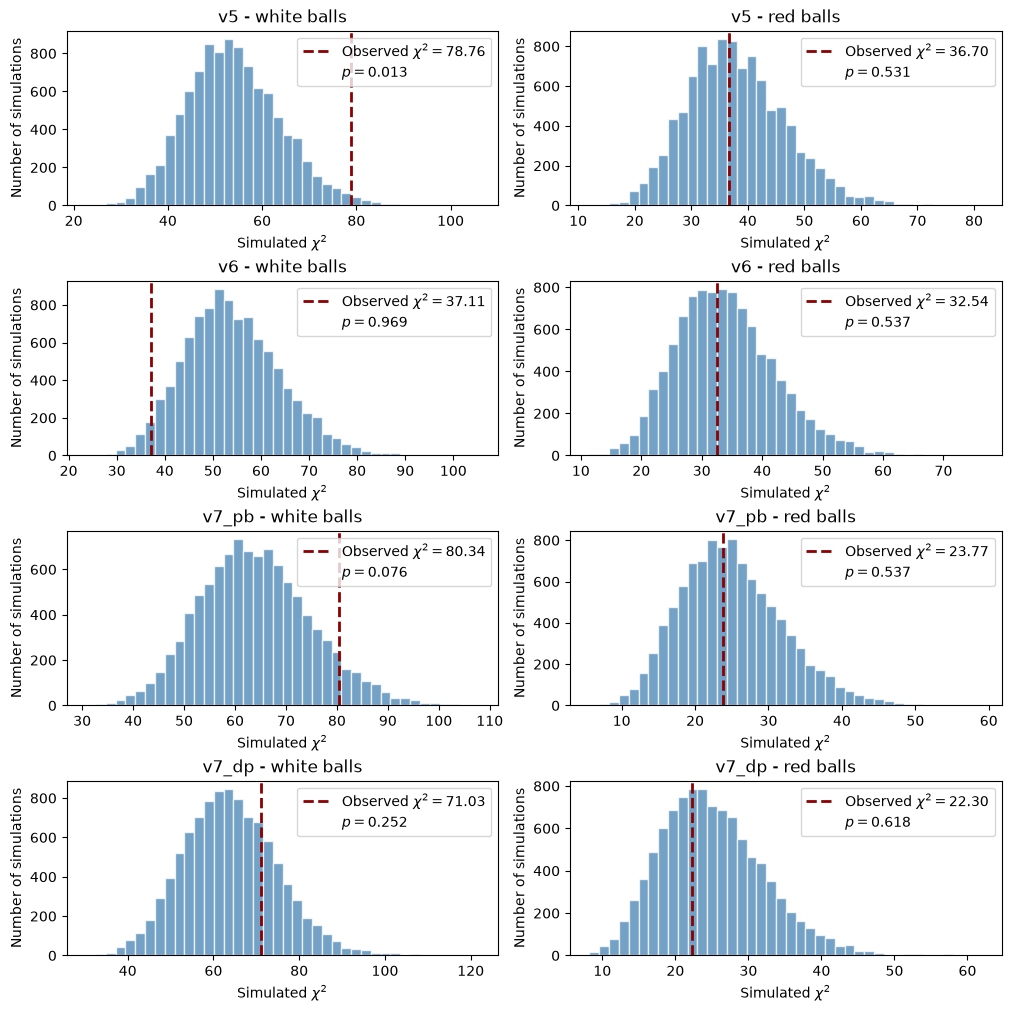

In [35]:
fig, axes = plt.subplots(4,2,figsize=(10, 10),layout="constrained")
axes = axes.flatten()
for i, (version, color, result) in enumerate(results_mc_test):
    plot_monte_carlo_distribution(result, f"{version} - {color}", axes[i])

The figure above shows how the observed $\chi^2$ values compare with the distributions produced by the MC simulations. Version 5 white balls stand out the most, with the observed value falling well into the right tail of the simulated distribution and giving an unadjusted p-value of $0.013$. Version 7 Powerball white balls also fall toward the right side, but the result is less unusual, with $p=0.069$. The remaining results are within or below the typical range of the fair simulations, providing no evidence of greater-than-expected unevenness. Next, we apply Holm correction to p-values using SciPy's built-in `multipletests` function.


In [36]:
reject, pvals, _, _ = multipletests(pvals=results_df["p_value"].to_numpy(),
                                    alpha=0.05,
                                    method="holm")

results_df["p_value_holm"] = pvals
results_df["reject_null"] = reject

display_df(results_df.head(10))

| draw_version   | ball_color   |   n_draws |   chi_sq |   p_value |   p_value_holm | reject_null   |
|:---------------|:-------------|----------:|---------:|----------:|---------------:|:--------------|
| v5             | white        |       300 |  78.7613 | 0.0131987 |       0.105589 | False         |
| v5             | red          |       300 |  36.7    | 0.531047  |       1        | False         |
| v6             | white        |       388 |  37.1082 | 0.968903  |       1        | False         |
| v6             | red          |       388 |  32.5412 | 0.537146  |       1        | False         |
| v7_pb          | white        |      1387 |  80.3449 | 0.0756924 |       0.529847 | False         |
| v7_pb          | red          |      1387 |  23.7671 | 0.537446  |       1        | False         |
| v7_dp          | white        |       773 |  71.0349 | 0.252375  |       1        | False         |
| v7_dp          | red          |       773 |  22.304  | 0.617938  |       1        | False         |

# Conclusion

Version 5 white balls showed the largest departure from uniformity, with $\chi^2=79.13$ and an unadjusted p-value of $0.013$. However, after accounting for all eight comparisons using the Holm correction, its adjusted p-value increased to $0.107$. None of the eight adjusted p-values was below the significance level of $0.05$, so the null hypothesis was not rejected for any distribution. Overall, the results do not provide statistically significant evidence that any of the ball distributions differs from the fair-drawing model.


# Appendix

In the previous analysis, we performed a MC hypothesis test on the distributions of both the red and white ball draws instead of applying the standard Pearson’s chi-square test directly. As previously discussed, the standard analytical test is valid for the red ball draws, but not for the white balls. This is because the white balls are drawn without replacement, which violates the core assumption of independent observations. To see how much this violation impacts our results, we can look at how much the p-values change when using the standard analytical chi-square test. We expect the analytical p-values for the red ball draws to be nearly identical to those calculated via MC simulation. Conversely, we expect to see a notable discrepancy for the white ball draws. Let's see if this is the case.

In [37]:
res = { "draw_version":[],
         "ball_color":[], 
         "chi_sq": [],
         "p_value": [],}

for version, df, n_white, n_red in datasets:
    
    observed_values = df[white_ball_cols].to_numpy(dtype=int).flatten()
    observed_counts = np.bincount(observed_values, minlength = n_white +1)[1:]

    _ = chisquare(observed_counts)
    res["draw_version"].append(version)
    res["ball_color"].append("white")
    res["chi_sq"].append(_.statistic)
    res["p_value"].append(_.pvalue)

    observed_values = df["red_ball"].to_numpy(dtype=int).flatten()
    observed_counts = np.bincount(observed_values, minlength = n_red +1)[1:]

    _ = chisquare(observed_counts)
    res["draw_version"].append(version)
    res["ball_color"].append("red")
    res["chi_sq"].append(_.statistic)
    res["p_value"].append(_.pvalue)

In [38]:
stat_ratios = pd.DataFrame(res)
stat_ratios["p_value_ratio"] = stat_ratios["p_value"]/results_df["p_value"]
stat_ratios["chi_sq_ratio"] = stat_ratios["chi_sq"]/results_df["chi_sq"]
display_df(stat_ratios[["draw_version", "ball_color", "chi_sq_ratio", "p_value_ratio"]])

| draw_version   | ball_color   |   chi_sq_ratio |   p_value_ratio |
|:---------------|:-------------|---------------:|----------------:|
| v5             | white        |              1 |        2.74309  |
| v5             | red          |              1 |        0.99713  |
| v6             | white        |              1 |        1.01679  |
| v6             | red          |              1 |        1.0037   |
| v7_pb          | white        |              1 |        1.91924  |
| v7_pb          | red          |              1 |        0.991467 |
| v7_dp          | white        |              1 |        1.49366  |
| v7_dp          | red          |              1 |        1.00032  |

The table above shows the ratios between the p-values calculated via the standard chi-square test and those computed via MC simulations. As expected, the ratios for the red ball draws are very close to unity. However, the p-values for the white ball draws are always considerably larger when computed using the standard chi-square test, which could lead to wrong conclusions about the null hypothesis. Now, let's look at how the empirical and theoretical distributions compare visually.

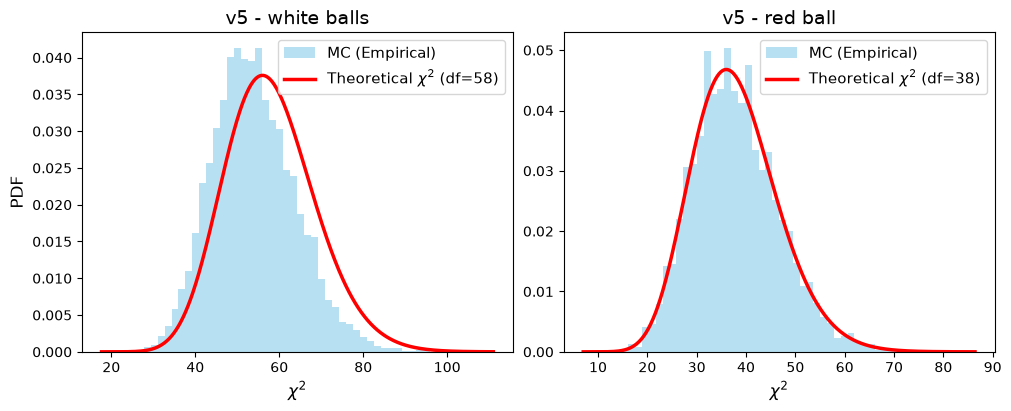

In [39]:
fig, axes = plt.subplots(1,2,figsize=(10, 4),layout="constrained")

mc_statistics = results_mc_test[0][2].null_distribution
x_min = mc_statistics.min() - 5
x_max = mc_statistics.max() + 5
x = np.linspace(x_min, x_max, 500)

df = 59-1
# Calculate the theoretical Chi-Square PDF
theoretical_pdf = chi2.pdf(x, df=df)


axes[0].hist(mc_statistics, bins=50, density=True, alpha=0.6, color='skyblue', label='MC (Empirical)')

axes[0].plot(x, theoretical_pdf, 'r-', lw=2.5, label=f'Theoretical $\chi^2$ (df={df})')
axes[0].set_title("v5 - white balls", fontsize=14)
axes[0].set_xlabel('$\chi^2$', fontsize=12)
axes[0].set_ylabel("PDF", fontsize=12)
axes[0].legend(fontsize=11)

#=======================================================================

mc_statistics = results_mc_test[1][2].null_distribution
x_min = mc_statistics.min() - 5
x_max = mc_statistics.max() + 5
x = np.linspace(x_min, x_max, 500)

df = 39-1
theoretical_pdf = chi2.pdf(x, df=38)
# Plot the Monte Carlo simulation empirical distribution
axes[1].hist(mc_statistics, bins=50, density=True, alpha=0.6, color='skyblue', label='MC (Empirical)')

# Plot the standard analytical Chi-Square curve
axes[1].plot(x, theoretical_pdf, 'r-', lw=2.5, label=f'Theoretical $\chi^2$ (df={df})')
axes[1].set_title('v5 - red ball', fontsize=14)
axes[1].set_xlabel('$\chi^2$', fontsize=12)
axes[1].legend(fontsize=11)

plt.show()

The figure above shows the simulated (MC) and theoretical distributions for the 5th version of the draw and both ball colors.As expected, the simulated results for the red ball match the theoretical curve almost perfectly. For the white balls, however, the standard theoretical curve is shifted too far to the right compared to our simulations. Because the theoretical curve is pushed to the right, it naturally calculates a much larger area in the tail, which explains why the standard test gives an inflated p-value.